# Show how nucleosome entropy is related to replication and gene expression level

May 14, 2024

**Goal:** Discern how nucleosome entropy is affected by:
1. Replication timing: early vs late
2. Gene expression, level and regulation


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.global_config import GlobalConstants

repl_timing = pd.read_csv(GlobalConstants.REPL_TIMING_FILEPATH).set_index('orf_name')
print(len(repl_timing), " genes with replication profiles")
repl_timing.head()

5250  genes with replication profiles


,timing,H_index
orf_name,,
YAL067W-A,53.314585,196
YAL067C,52.304185,194
YAL064C-A,52.809385,195
YAL064W,51.798985,193
YAL063C-A,51.798985,193


In [5]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.045
1001/5574 - 00:00:05.845
2001/5574 - 00:00:11.801
3001/5574 - 00:00:17.770
4001/5574 - 00:00:23.801
5001/5574 - 00:00:29.773


In [6]:
promoter_analysis.correct_f_images_by_strand()

In [7]:
# Let's get the gene expression at the replication time.

from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

ge_analysis = GeneExpressionAnalysis(
    'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/')
ge_analysis.load_gene_expression_fs()


In [8]:
from src.gene_chromatin_replication_analysis import GeneChromatinReplicationAnalysis

gene_chrom_repl_analysis = GeneChromatinReplicationAnalysis(promoter_analysis,
                                                            ge_analysis,
                                                            repl_timing)

5232 genes with replication timing
Shape of the f images:  (5232, 227, 8, 25)


In [9]:
from src.helpers import calc_entropy

In [260]:
gene_chrom_repl_analysis.compute_gene_nuc_entropy()

Shape of the f images:  (5232, 227, 8, 25)
Shape of the bins to compute entropy over:  (5232, 128, 17)


/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_entropy.py:135: RuntimeWarning: invalid value encountered in divide
  pk = 1.0*pk / np.sum(pk, axis=axis, keepdims=True)


In [11]:
gene_chrom_repl_analysis.normalized_entropy_df.to_csv('output/normalized_gb_entropy.csv')

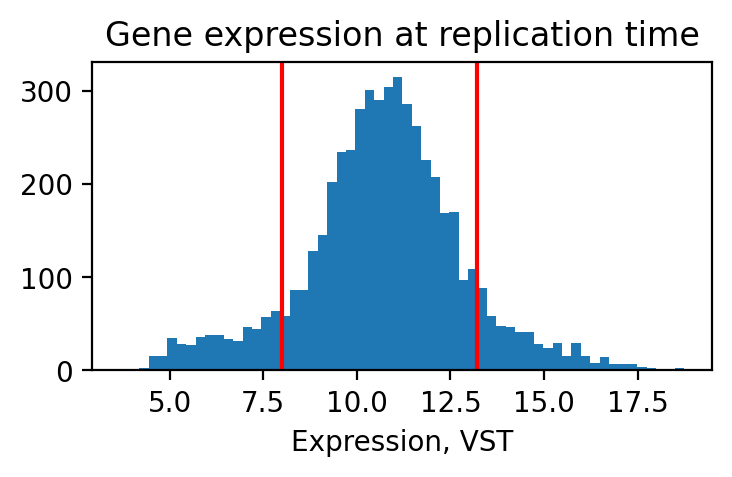

In [12]:
tx_repl = gene_chrom_repl_analysis.geneset_repl.expression_at_replication
plt.figure(figsize=(4, 2))
plt.hist(tx_repl, bins=60)
plt.title("Gene expression at replication time")
plt.xlabel("Expression, VST")

q25, q75 = np.quantile(tx_repl, q=[0.1, 0.9])

plt.axvline(q25, c='red')
plt.axvline(q75, c='red')

np.sum(tx_repl > q75), np.sum(tx_repl <  q25)

high_tx_orfs = tx_repl.loc[tx_repl > q75].index
low_tx_orfs = tx_repl.loc[tx_repl < q25].index

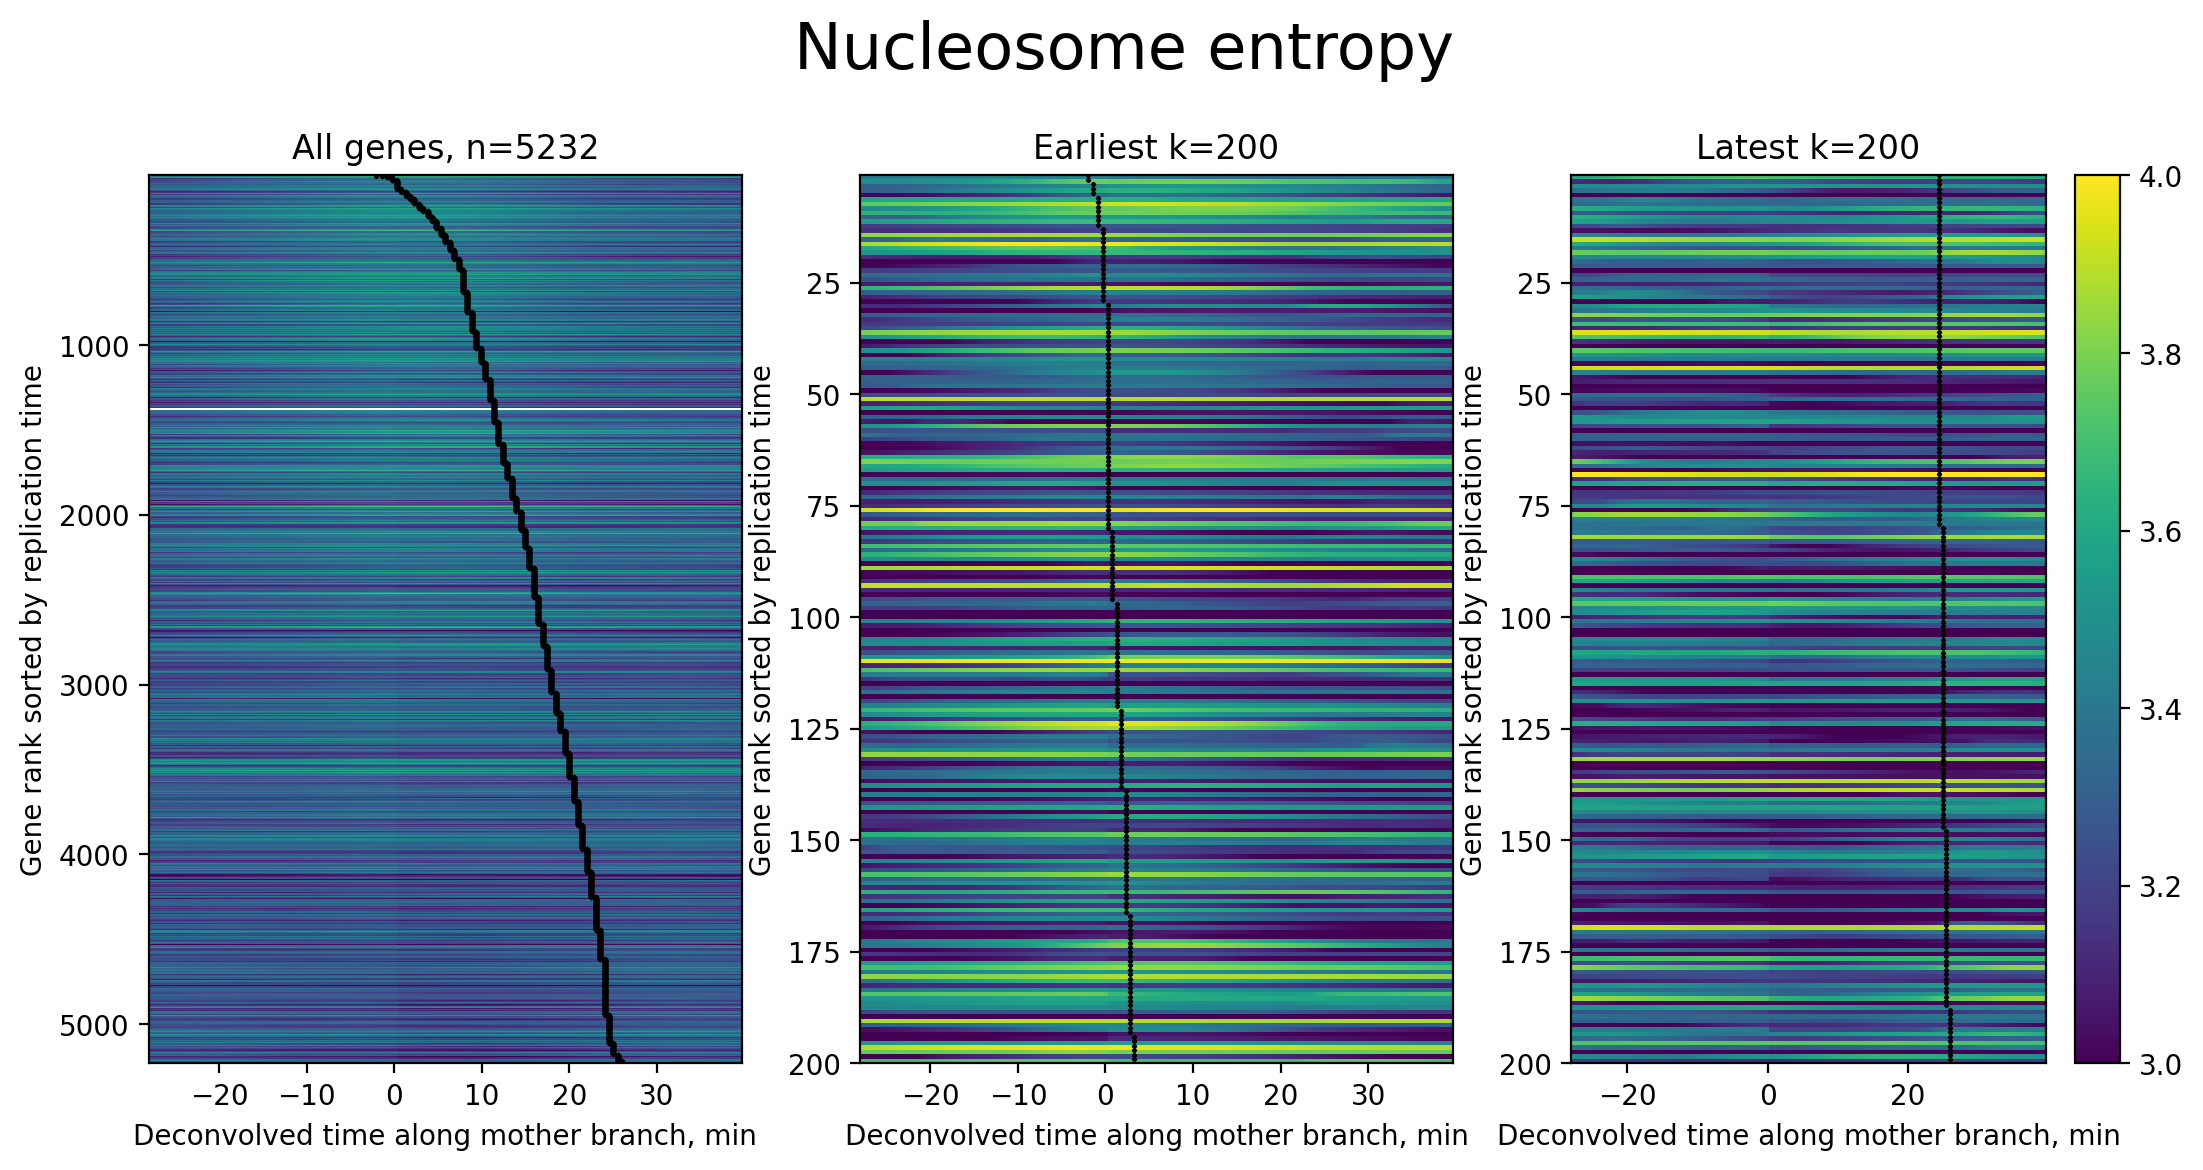

In [13]:
gene_chrom_repl_analysis.plot_early_late_entropy_hm_comparision(normalize=True)

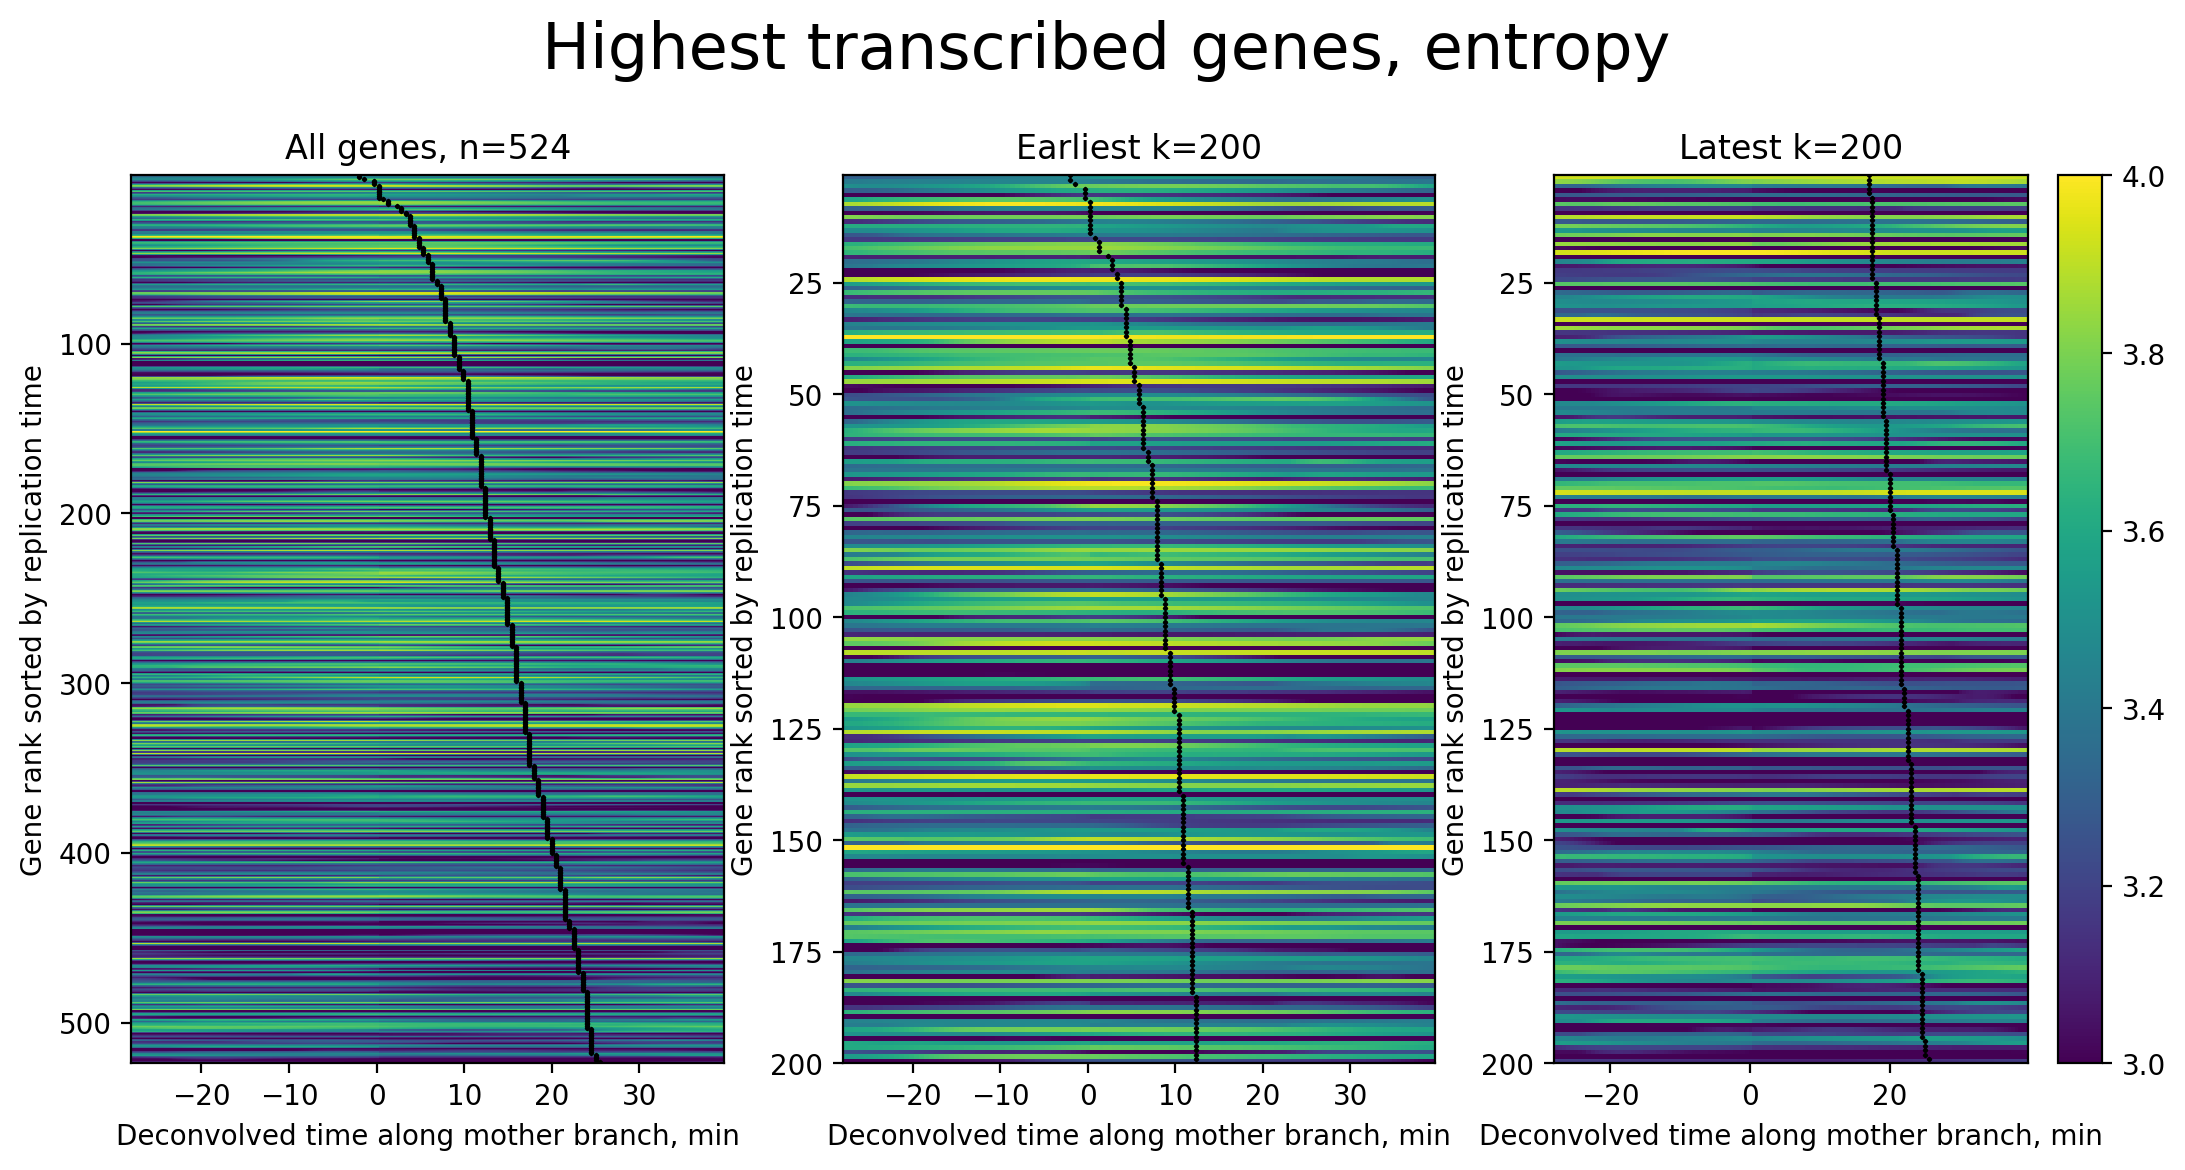

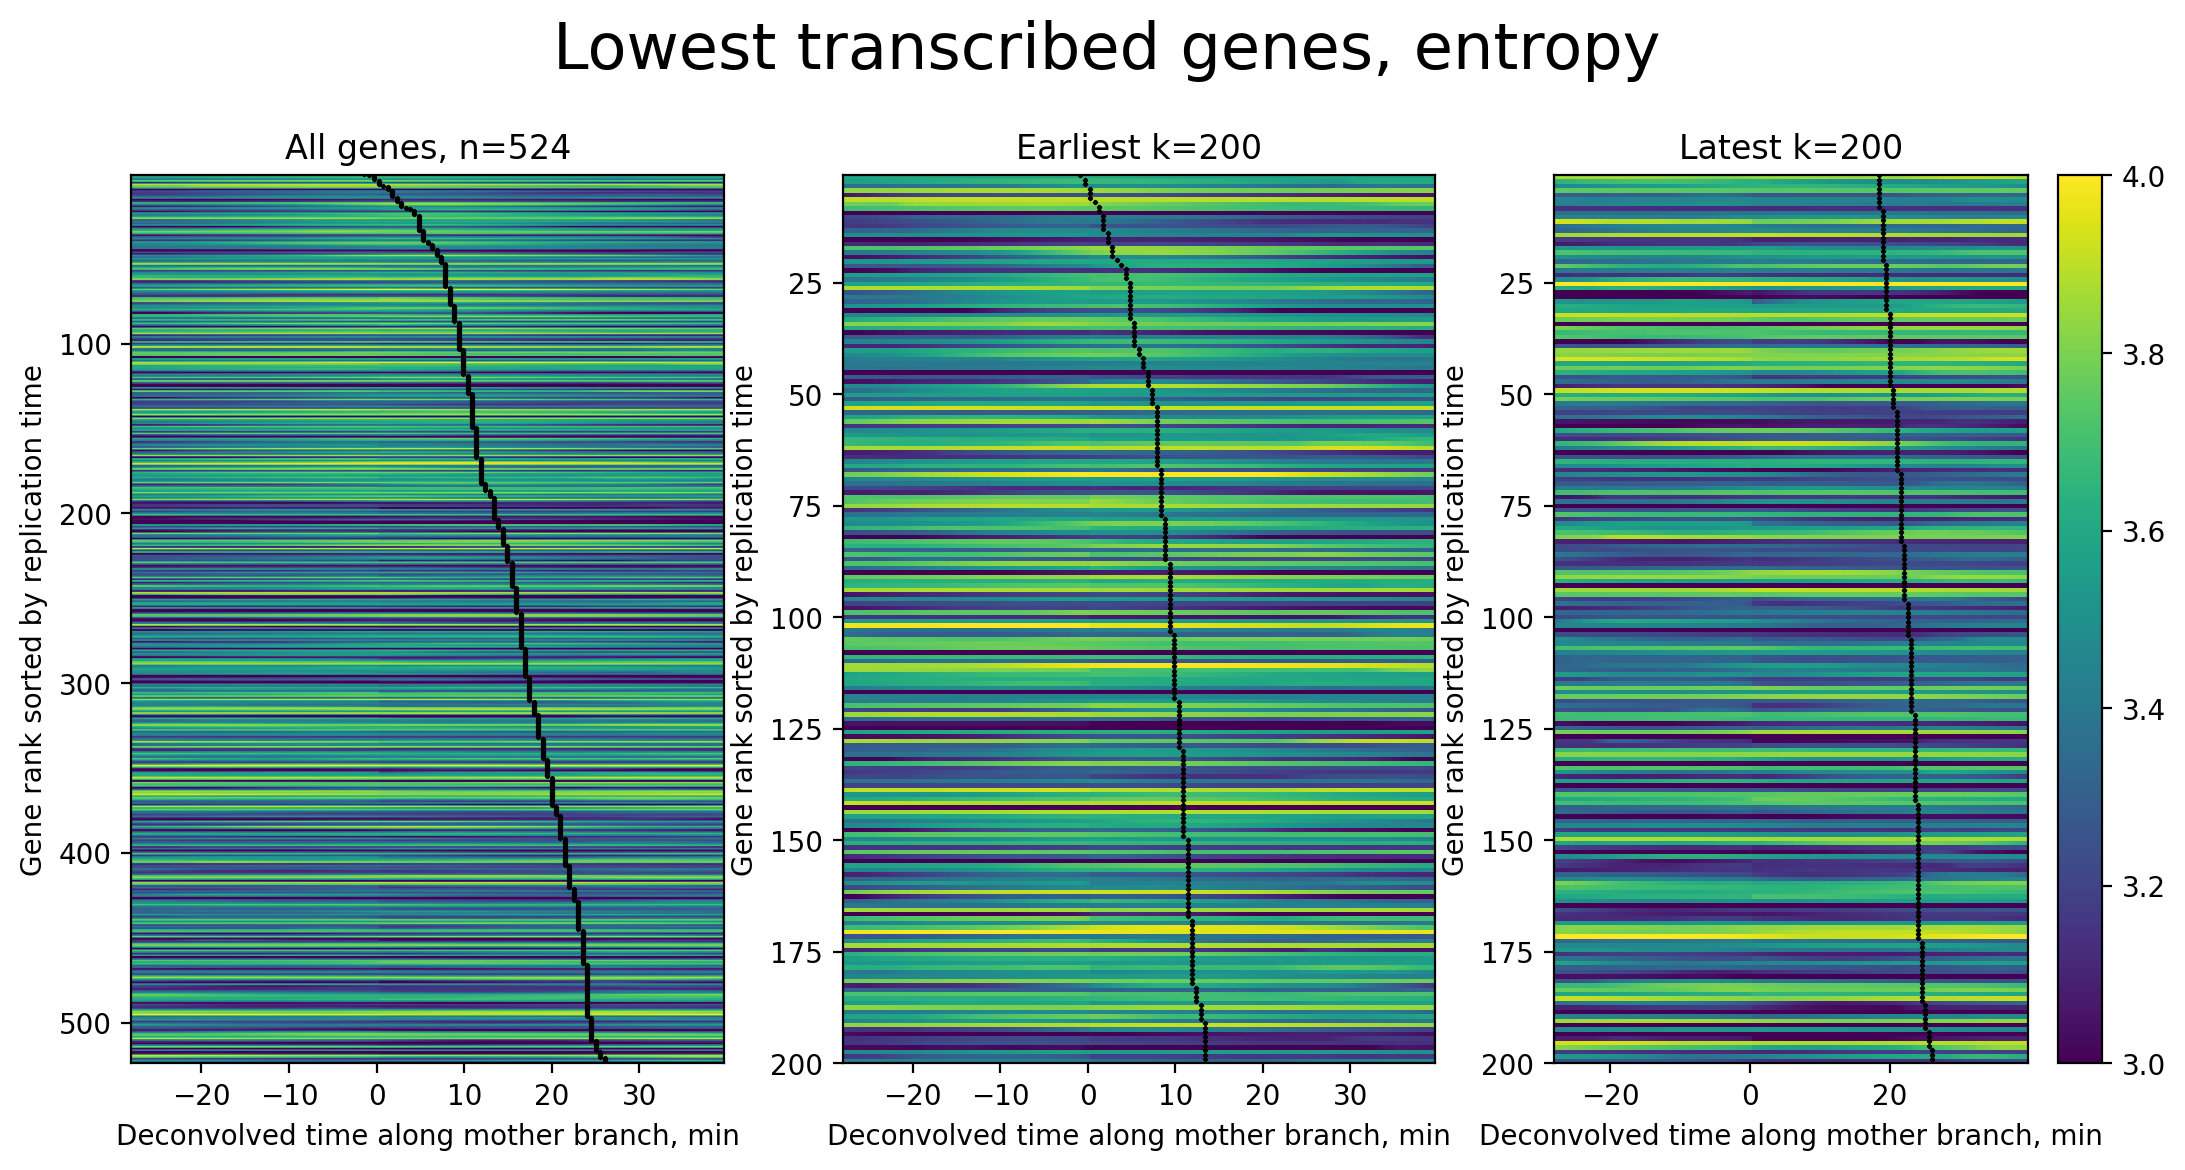

In [14]:
gene_chrom_repl_analysis.plot_early_late_entropy_hm_comparision(normalize=True,
    subset_orfs=high_tx_orfs, title="Highest transcribed genes, entropy")
gene_chrom_repl_analysis.plot_early_late_entropy_hm_comparision(normalize=True,
    subset_orfs=low_tx_orfs, title="Lowest transcribed genes, entropy")


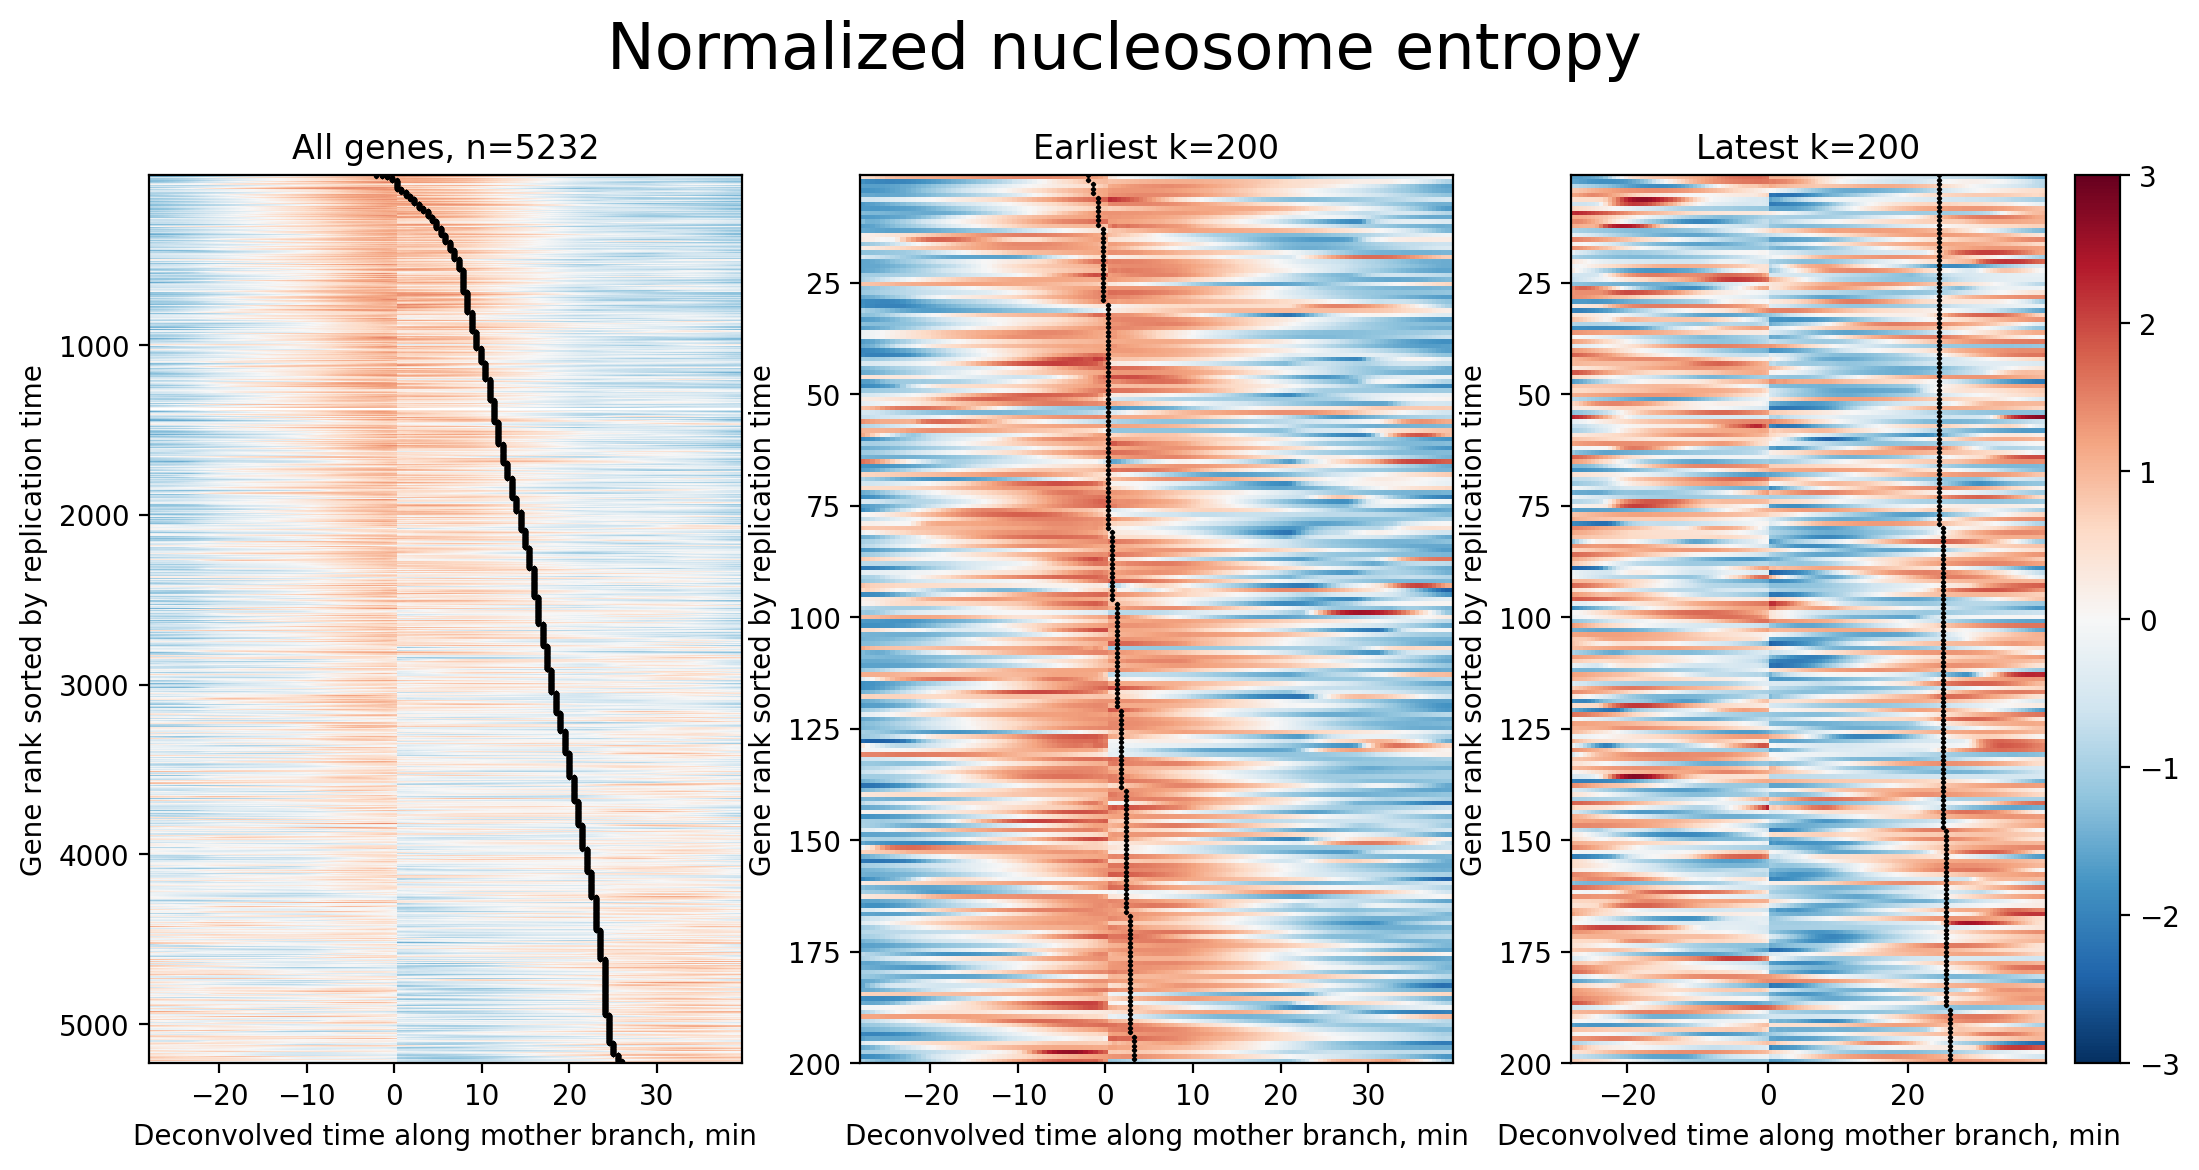

In [15]:
# In the unnormalized entropy scores, can we see a global effect of the replication fork
# passing through early and late genes?
gene_chrom_repl_analysis.plot_early_late_entropy_hm_comparision()


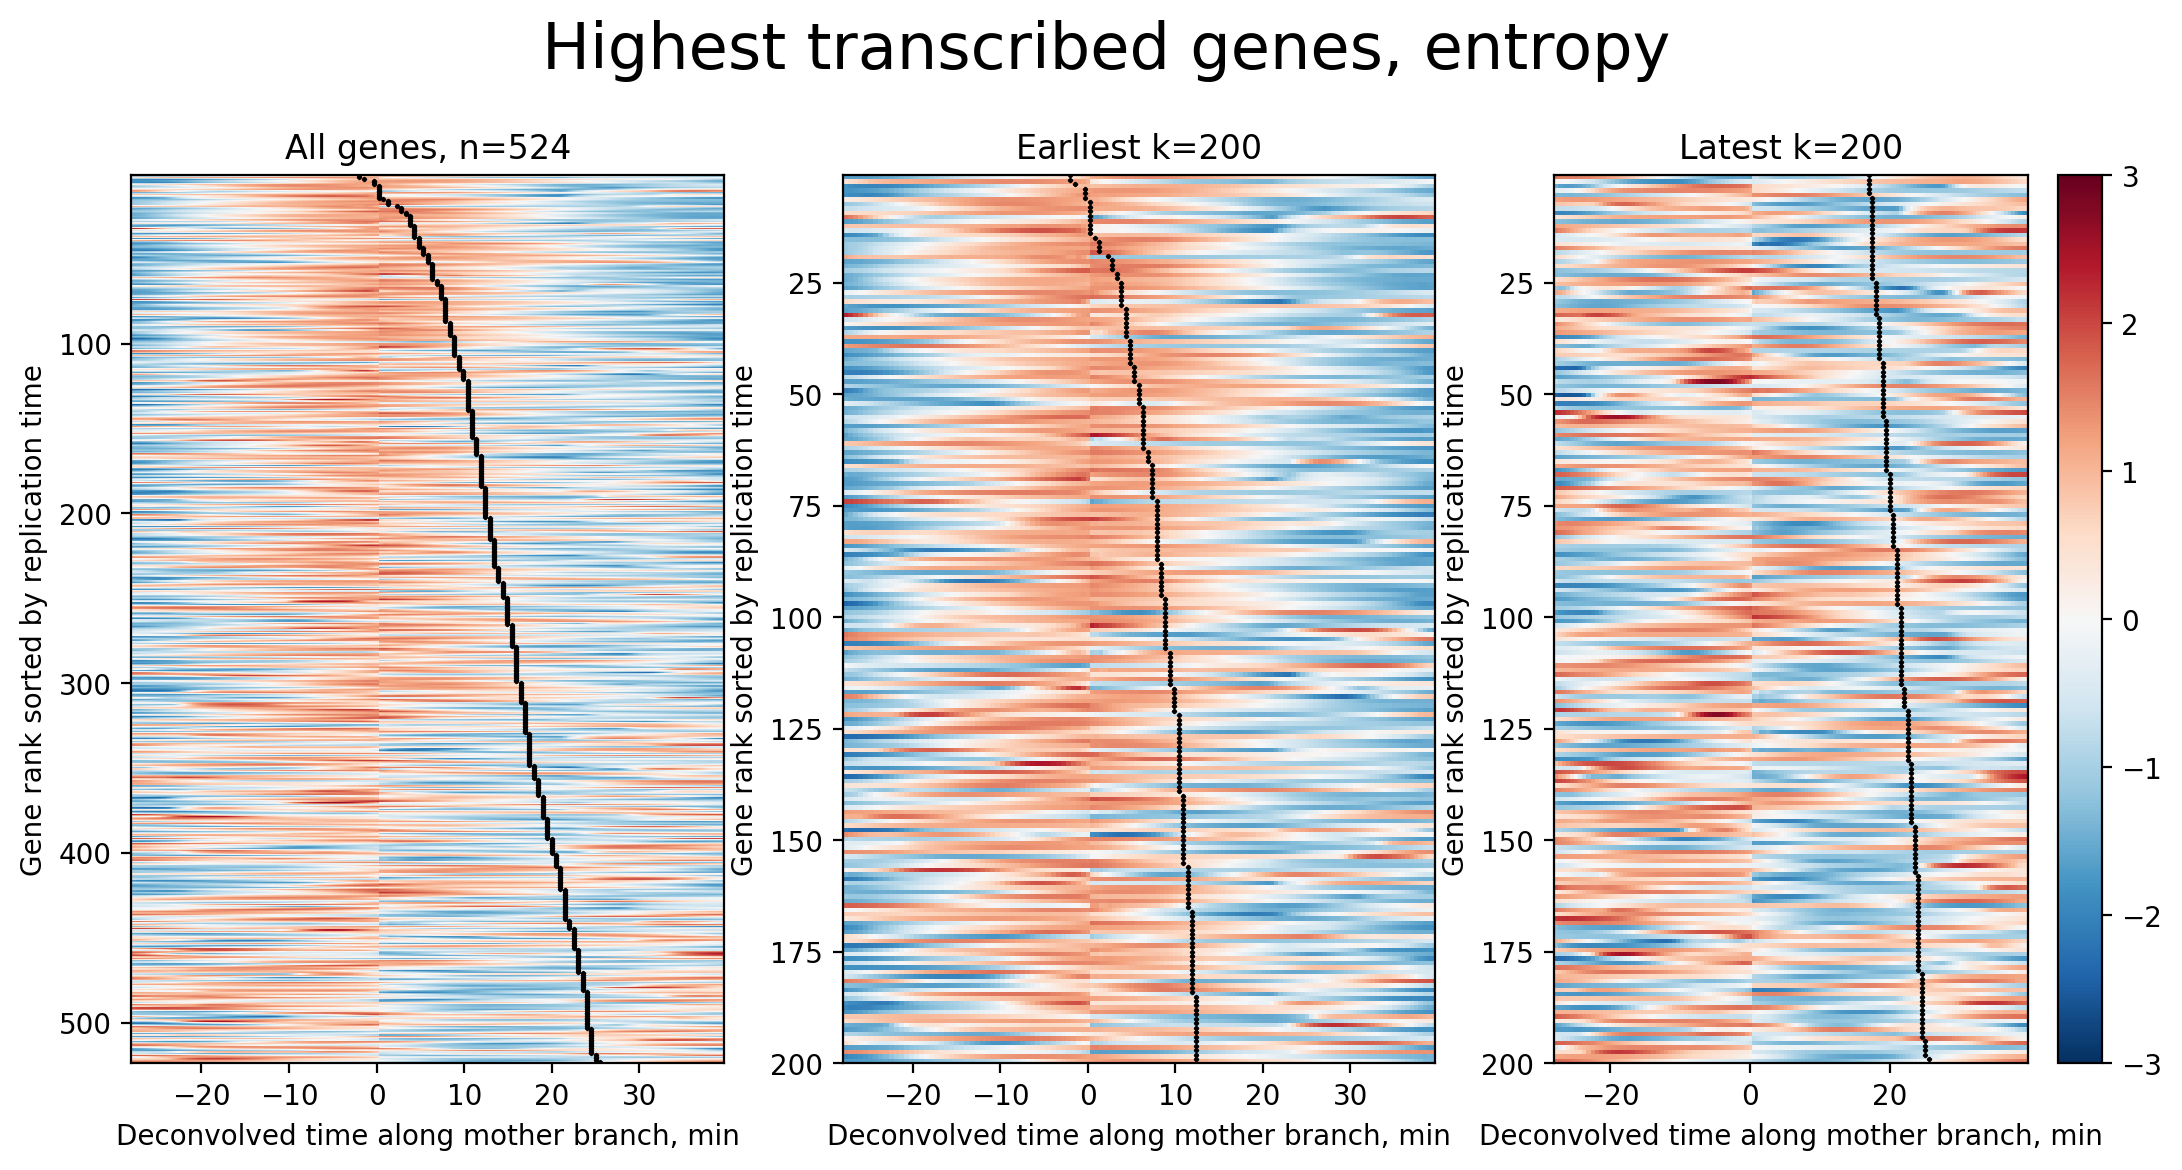

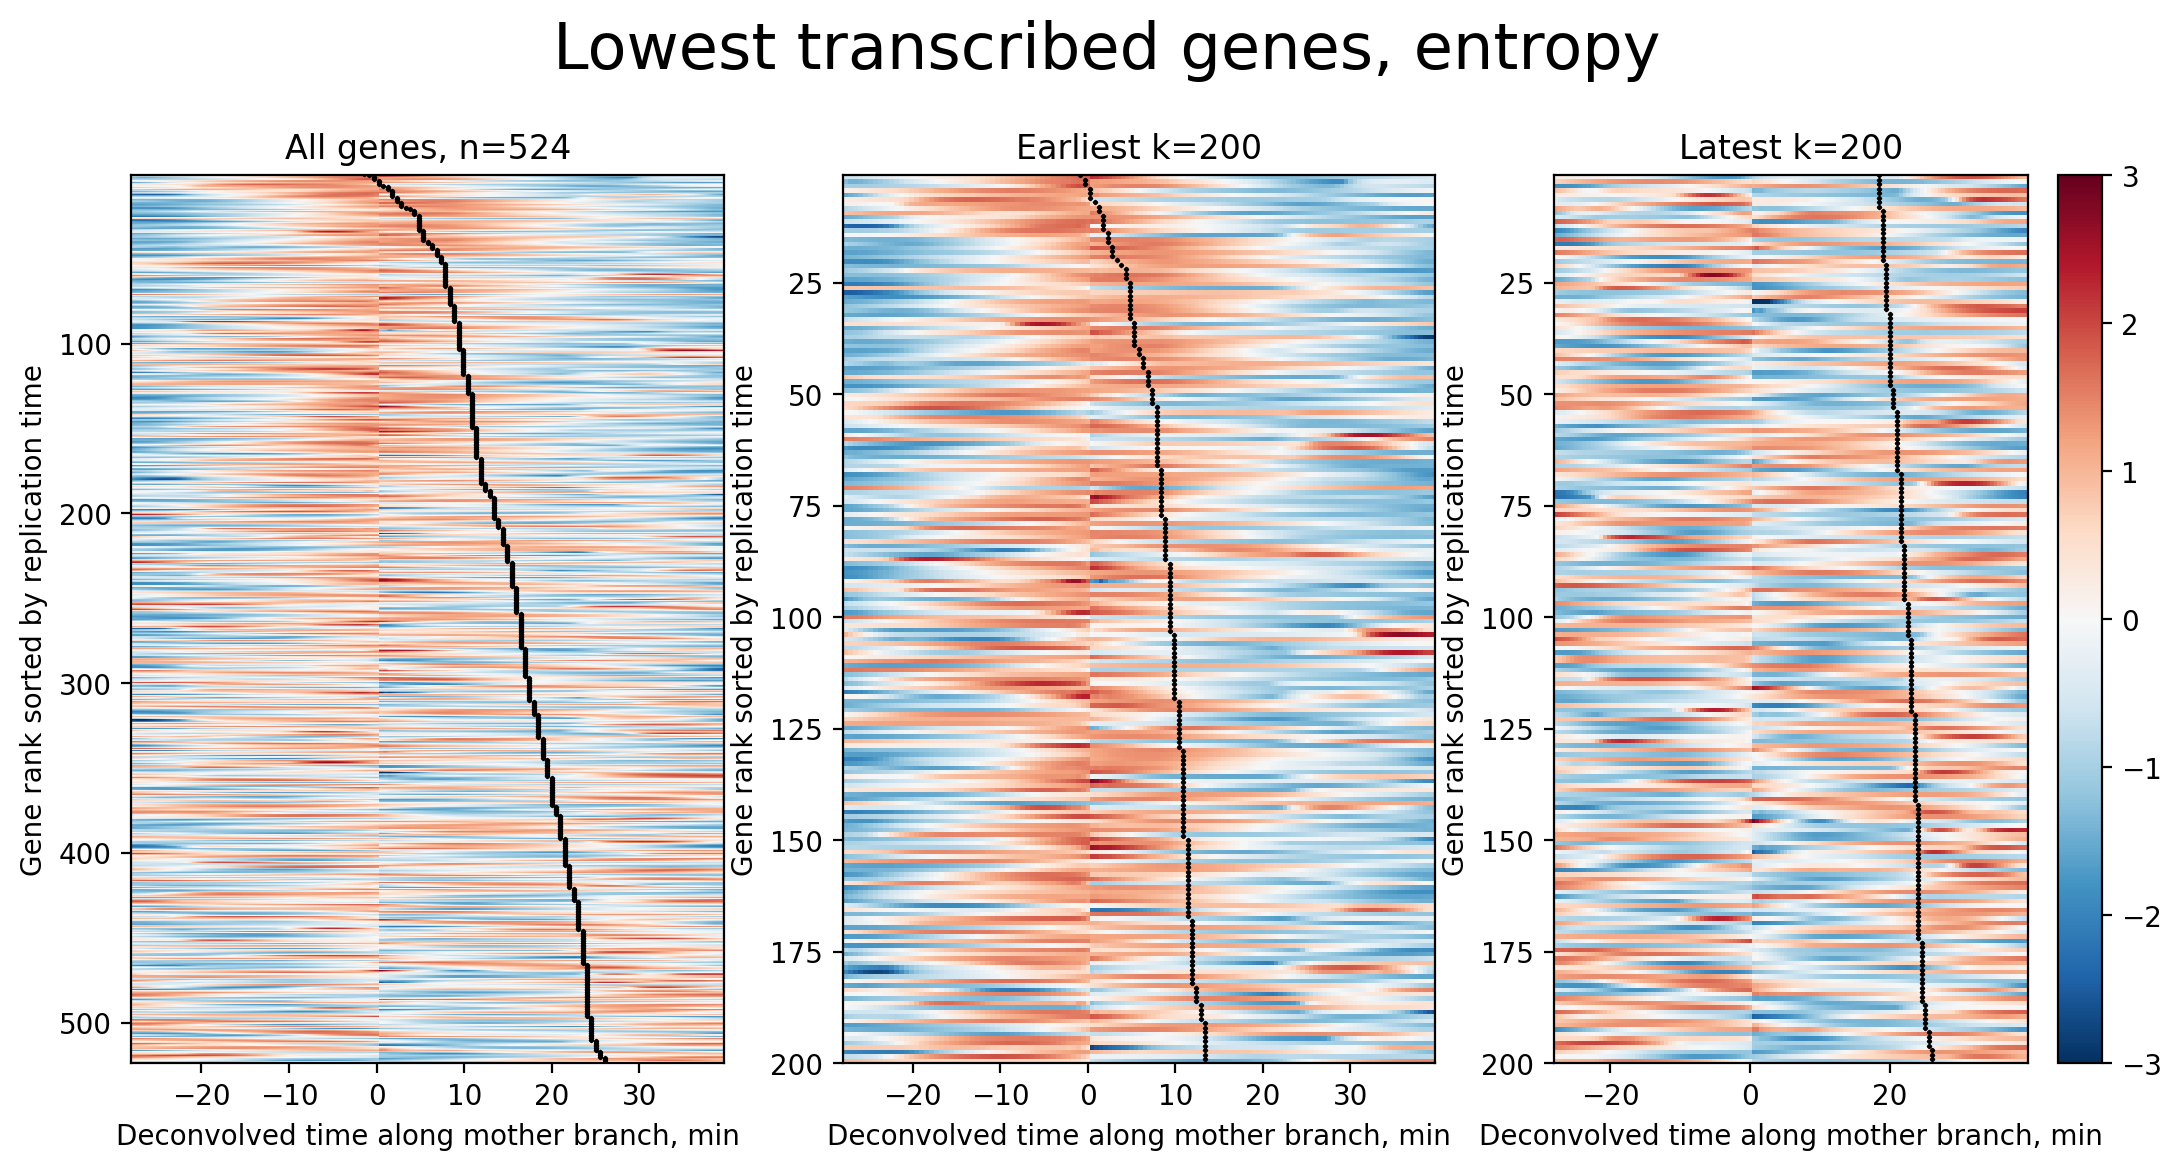

In [17]:
gene_chrom_repl_analysis.plot_early_late_entropy_hm_comparision(normalize=False,
    subset_orfs=high_tx_orfs, title="Highest transcribed genes, entropy")
gene_chrom_repl_analysis.plot_early_late_entropy_hm_comparision(normalize=False,
    subset_orfs=low_tx_orfs, title="Lowest transcribed genes, entropy")


# Analysis to work through absolute entropy values

Absolute entropy values make more sense and help us have an idea on the overall entropy across the genome. But the values span and oscillate along different entropy values making it difficult to identify patterns in oscillation for early vs late replicating genes without normalization.

If we want to avoid normalization, which may add an additional layer of complexity, we can try to break the entropy scores in to quantiles that make it easier to compare early and late replicating genes. 

**Idea:** Gene nucleosomes have different baseline levels of entropy (some sets of nucleosomes shift more than others). So let's split them up. Perhaps these are nucleosomes that more commonly pickup certain histone variants (possible side analysis).

**Hypothesis**: Genes with nucleosomes that are more entropic overall, have a differential timing of peak entropy alongside replication than nucleosomes with less entropy.

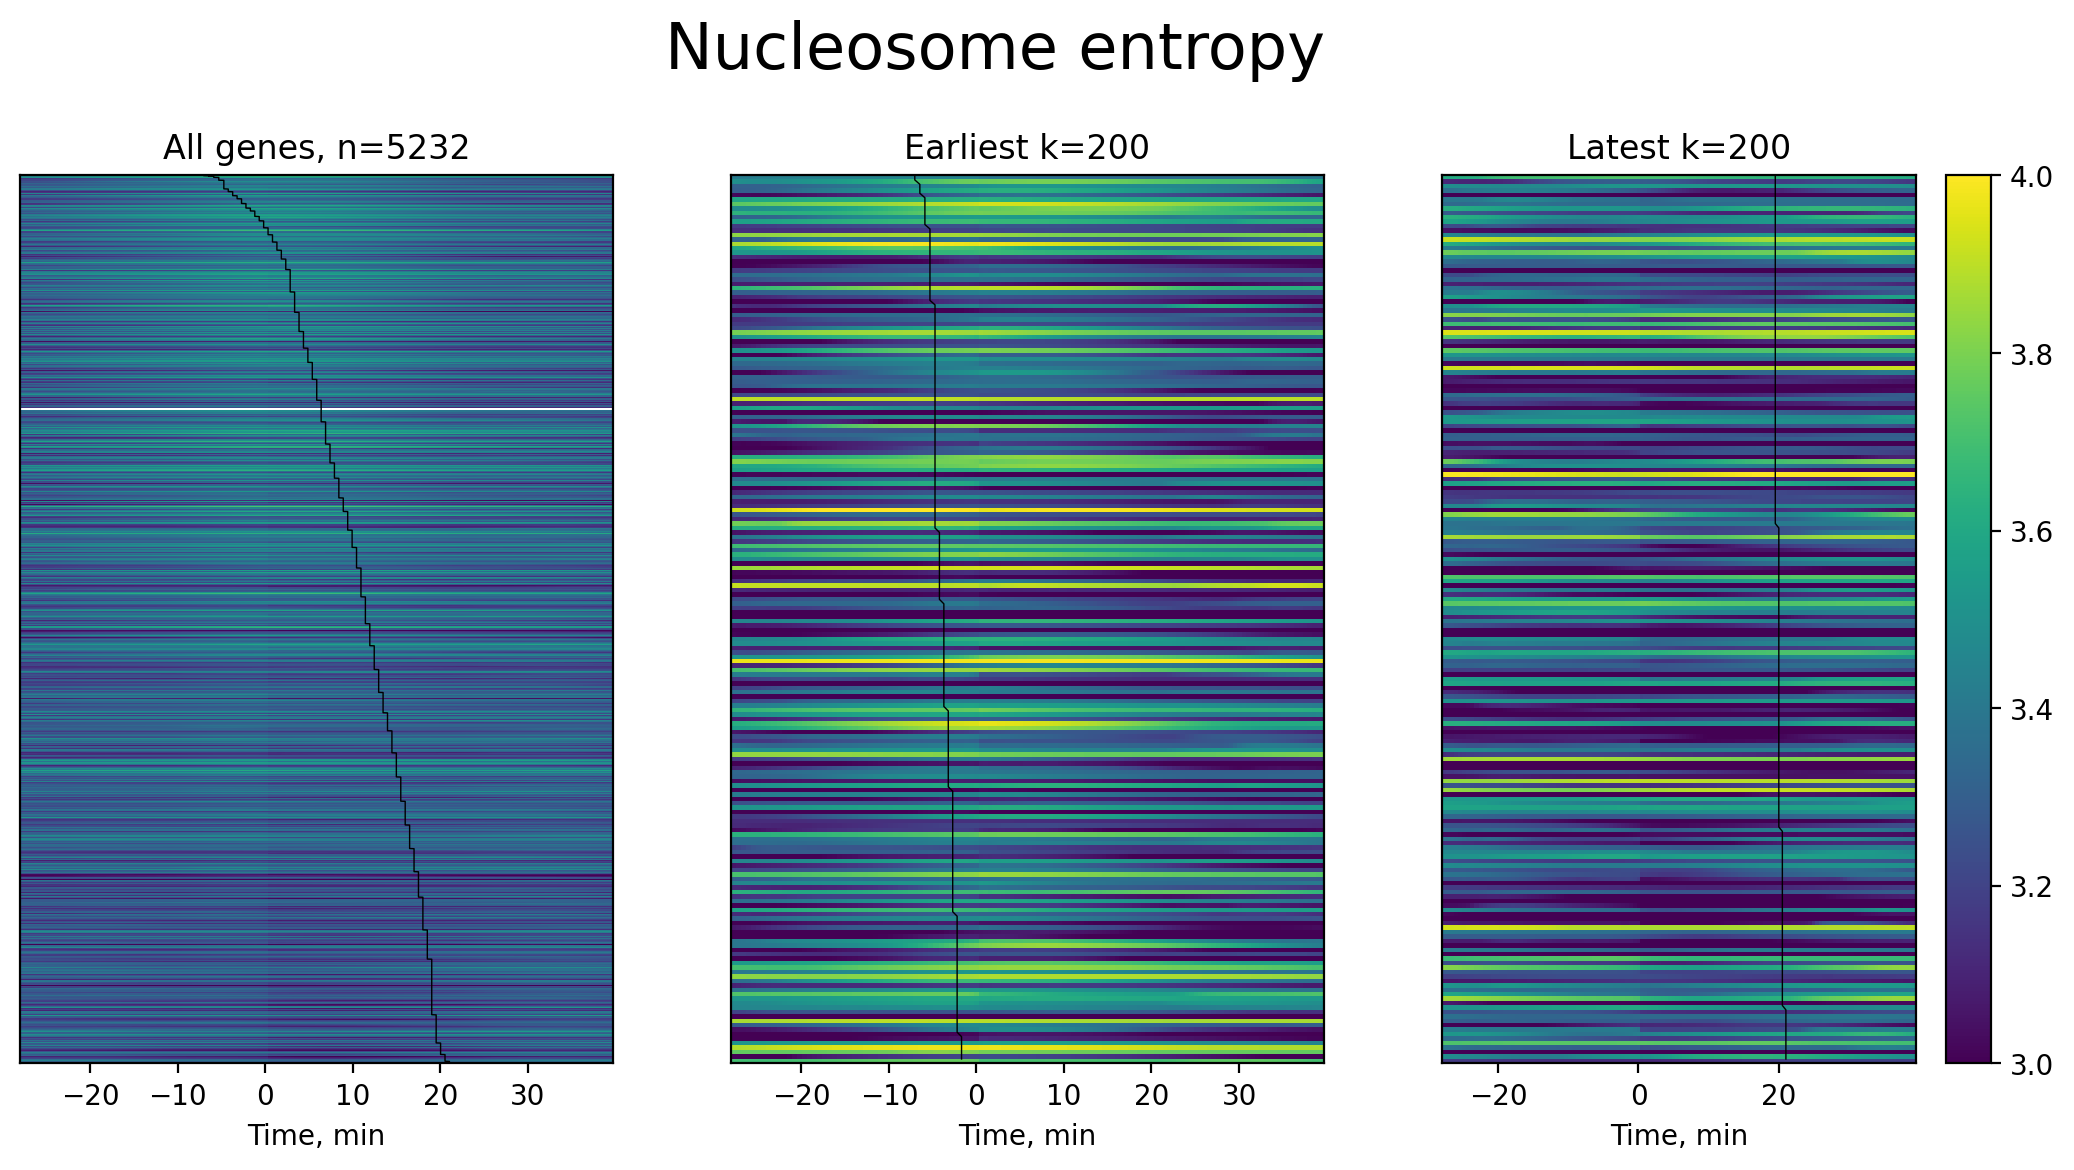

In [777]:
gene_chrom_repl_analysis.set_entropy_vs_tx_df(mode='at_replication')
gene_chrom_repl_analysis.plot_early_late_entropy_hm_comparision(normalize=True)

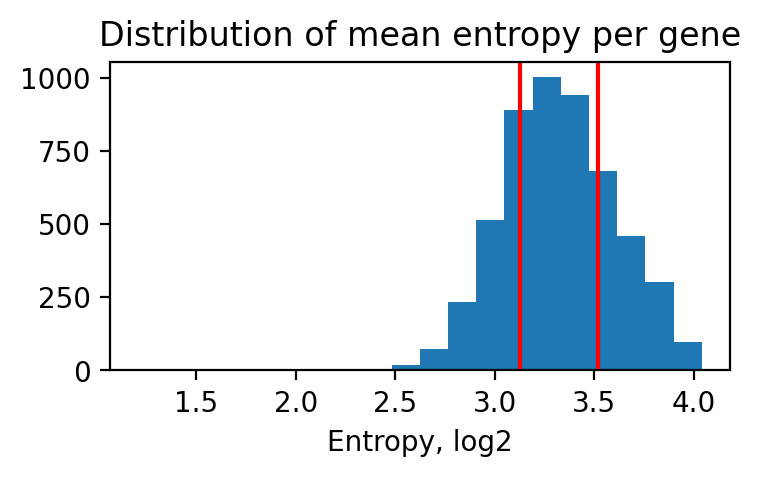

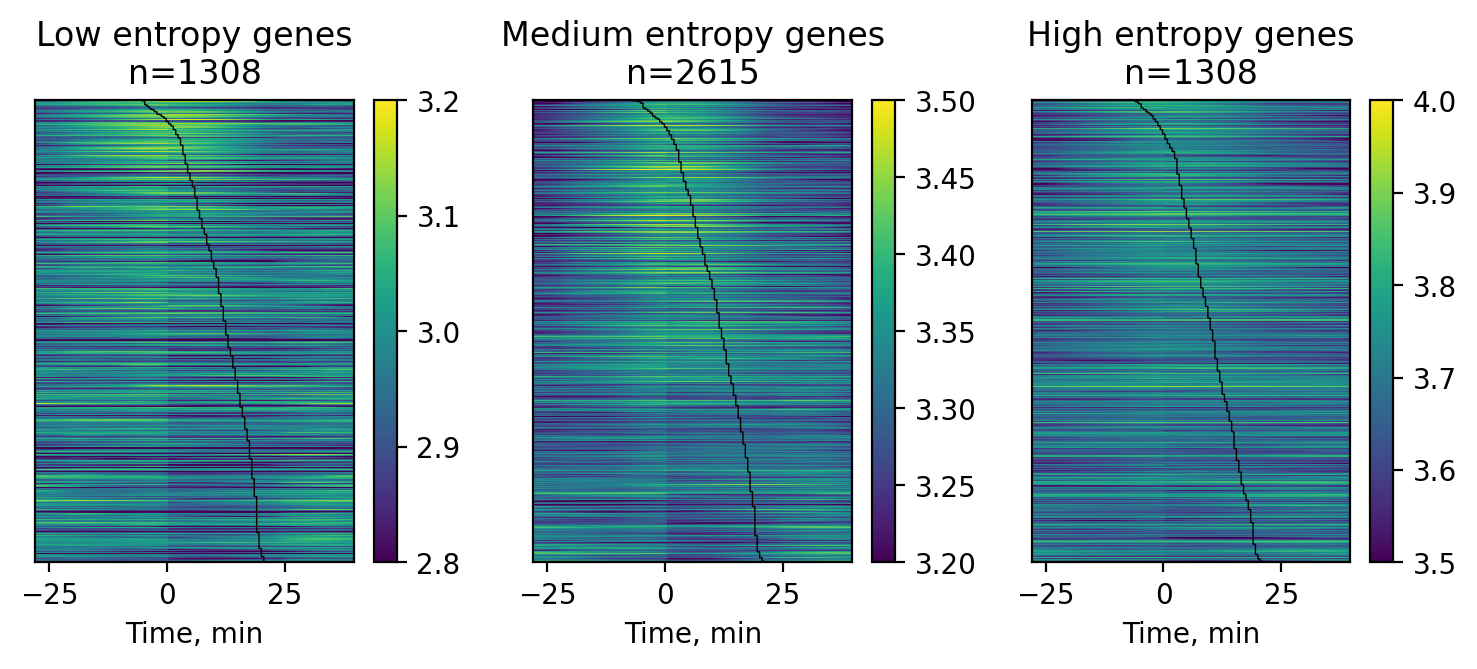

In [778]:
gene_chrom_repl_analysis.plot_hi_lo_entropy_hm_analysis()

There appears to be some differences in replication timing depending on the average entropy of the gene nucleosomes.

If we were to examining these genes by, early genes and late genes. How would this pattern change?
What is the question?

**Hypothesis:** High entropic genes, have a higher baseline level of transcription and are less likely to be affected by the replication fork disruption.

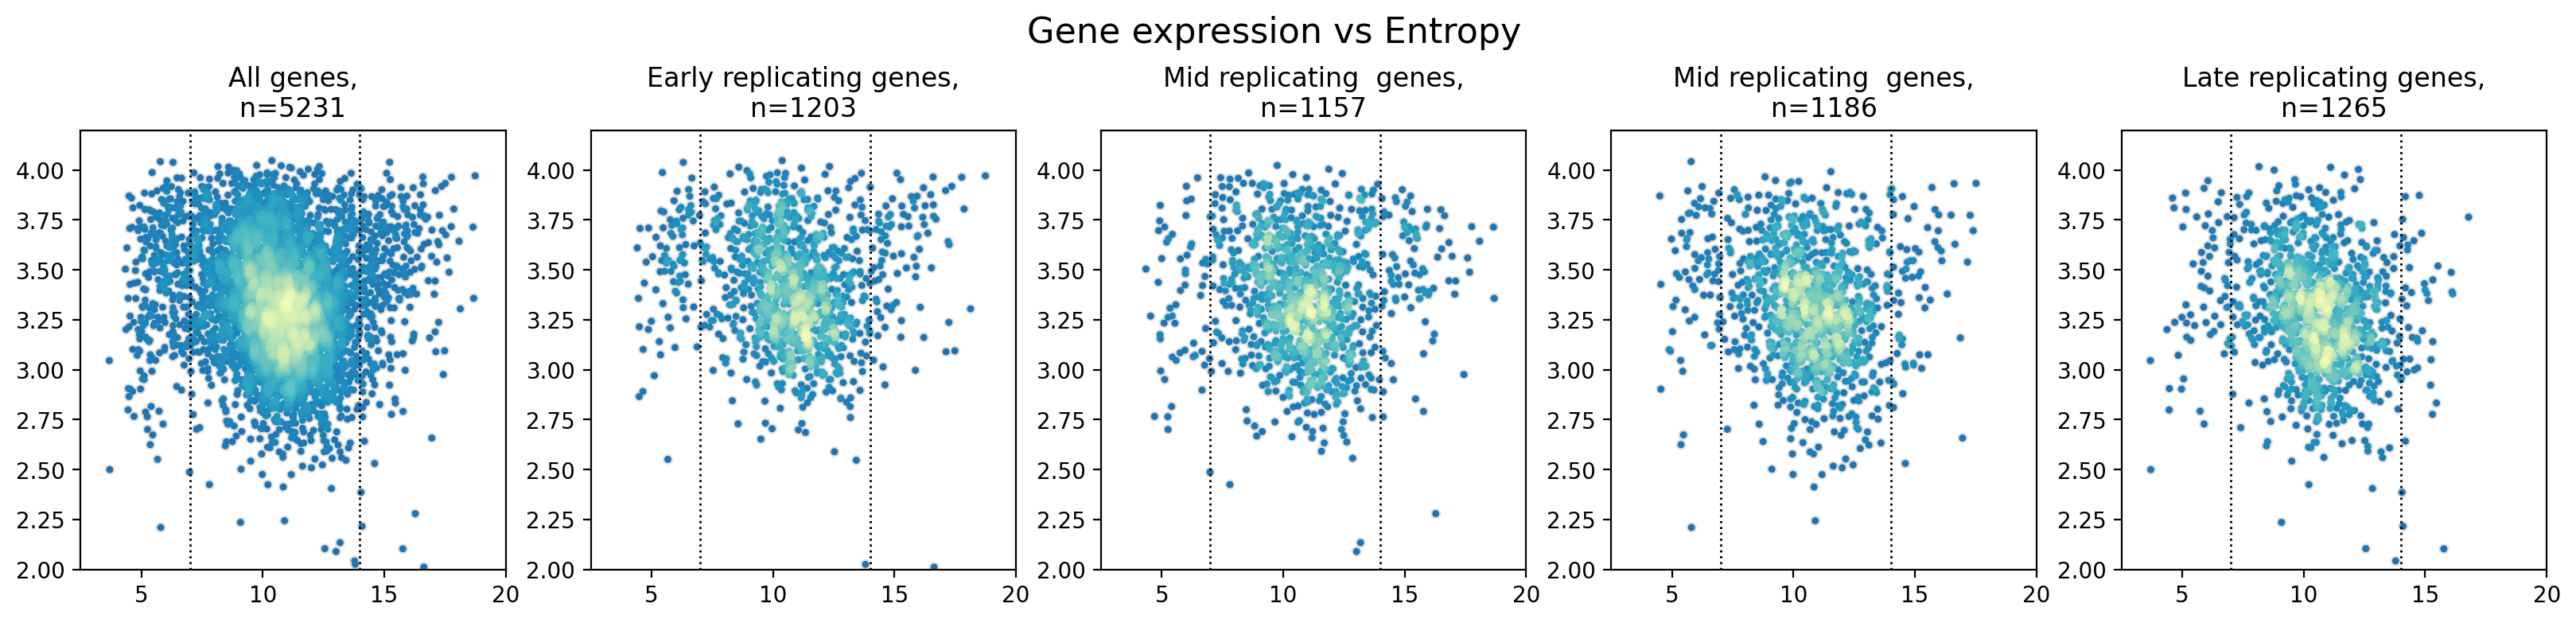

In [597]:
# For the previous analysis it made sense to use mean entropy because we are 
# plotting the whole  time course

# But here, we are plotting the expresison at replication time
# so it would be logical to use the entropy value at replication time
x_cutoffs = [7, 14]

# Snap shot of genomic and chromatin landscape at replication time:
gene_chrom_repl_analysis.plot_entropy_vs_expression_analysis(entropy_at_repl_time=True,
    x_cutoffs=x_cutoffs)


Because this plot shows mean entropy, the hypothesis cannot be concluded.

But interesting observation from this series:
1. Early replicating genes have differential expression and entropy for high and lowly expressed genes.
2. High and low expressed genes (possibly regulated), tend to have higher average entropy values in early replicating genes compared to late replicating gene.
 - Maybe there a regulatory implications here.

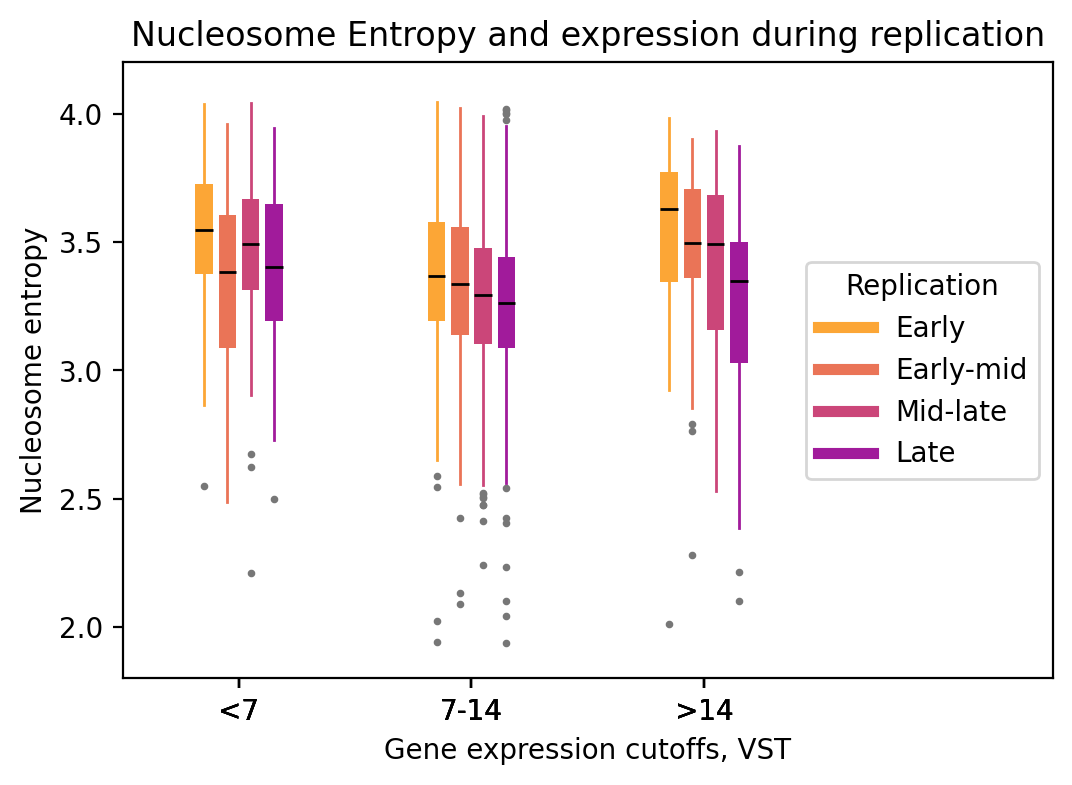

In [568]:
gene_chrom_repl_analysis.plot_box_plot_entropy_ge(x_cutoffs)

# Reflect: Biological implications

Why is the chromatin for early replicating genes with high transcription more entropic, than late replicating genes with high transcription?

Hypothesis:
- Late replicating genes must be more organized in order to handle late replication stress
- Early replicating genes are more adaptable, to allow time for replication repair.

How can we provide evidence for this hypothesis? What genes are in these two groups and why? What genes are activated by the time these genes are being replicated?


# Plan: Compute the average entropy and gene expression values through replication. Delta of 5 and 10 minutes

    
Goal: Compute metrics based on range rather than replication point to reduce variation in replication timing estimation.

Redo the analysis of early and late replication with the average delta values and observe if the result stands, and/or if there are other observations made when the delta range is in effect.

Try for 5 and 10 minutes. How robust are these results? How much does increasing the average window affect the results? We should expect that +/- 10 minutes (a 20 minute) window should reduce the signal. And +/- 5 minutes (10 minute window) should reduce noise.


In [644]:
gene_chrom_repl_analysis.compute_replication_window_deltas()

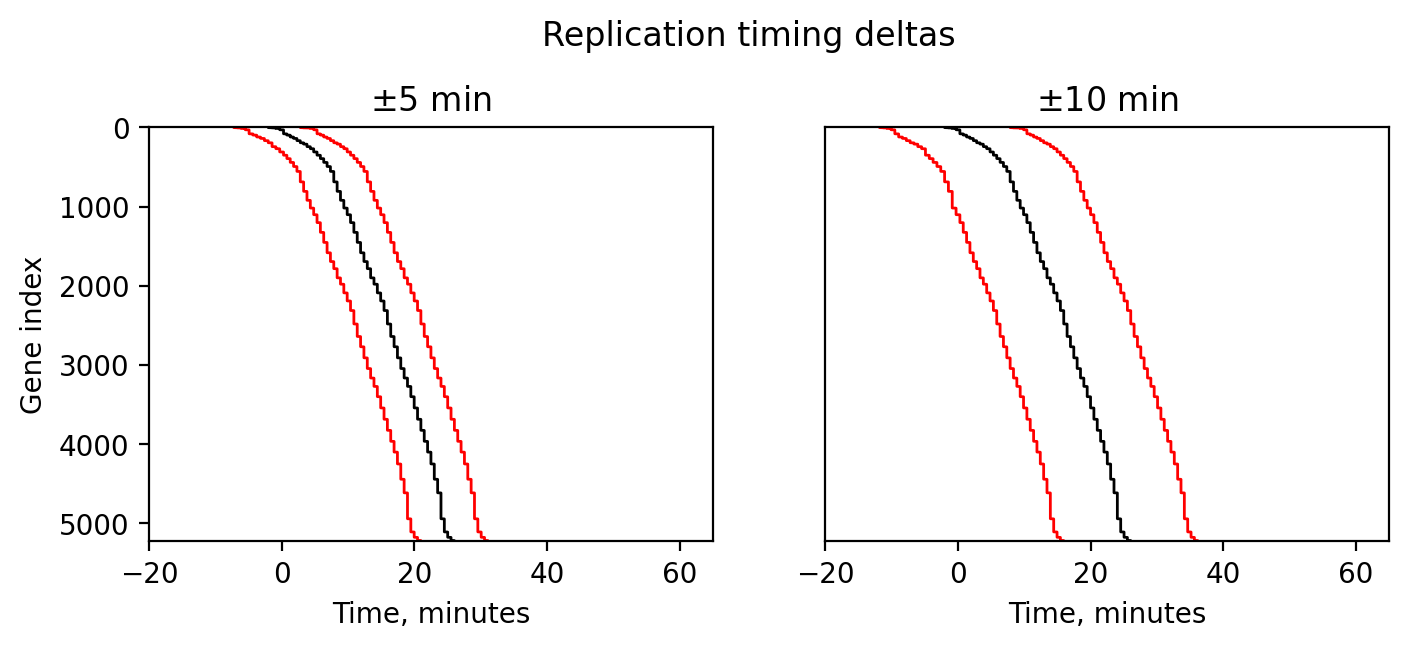

In [675]:
gene_chrom_repl_analysis.plot_replication_delta_windows()

In [745]:
# Compute the entropy and gene expression 
# averaged across the replication timing delta values
#
# Compute the -delta and +delta values
gene_chrom_repl_analysis.compute_delta_entropies()
gene_chrom_repl_analysis.compute_delta_gene_expressions()

In [774]:
x_cutoffs = [7, 14]

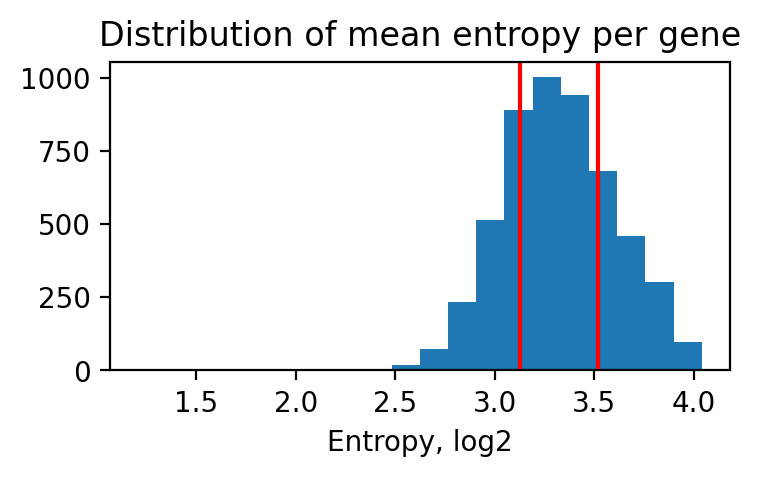

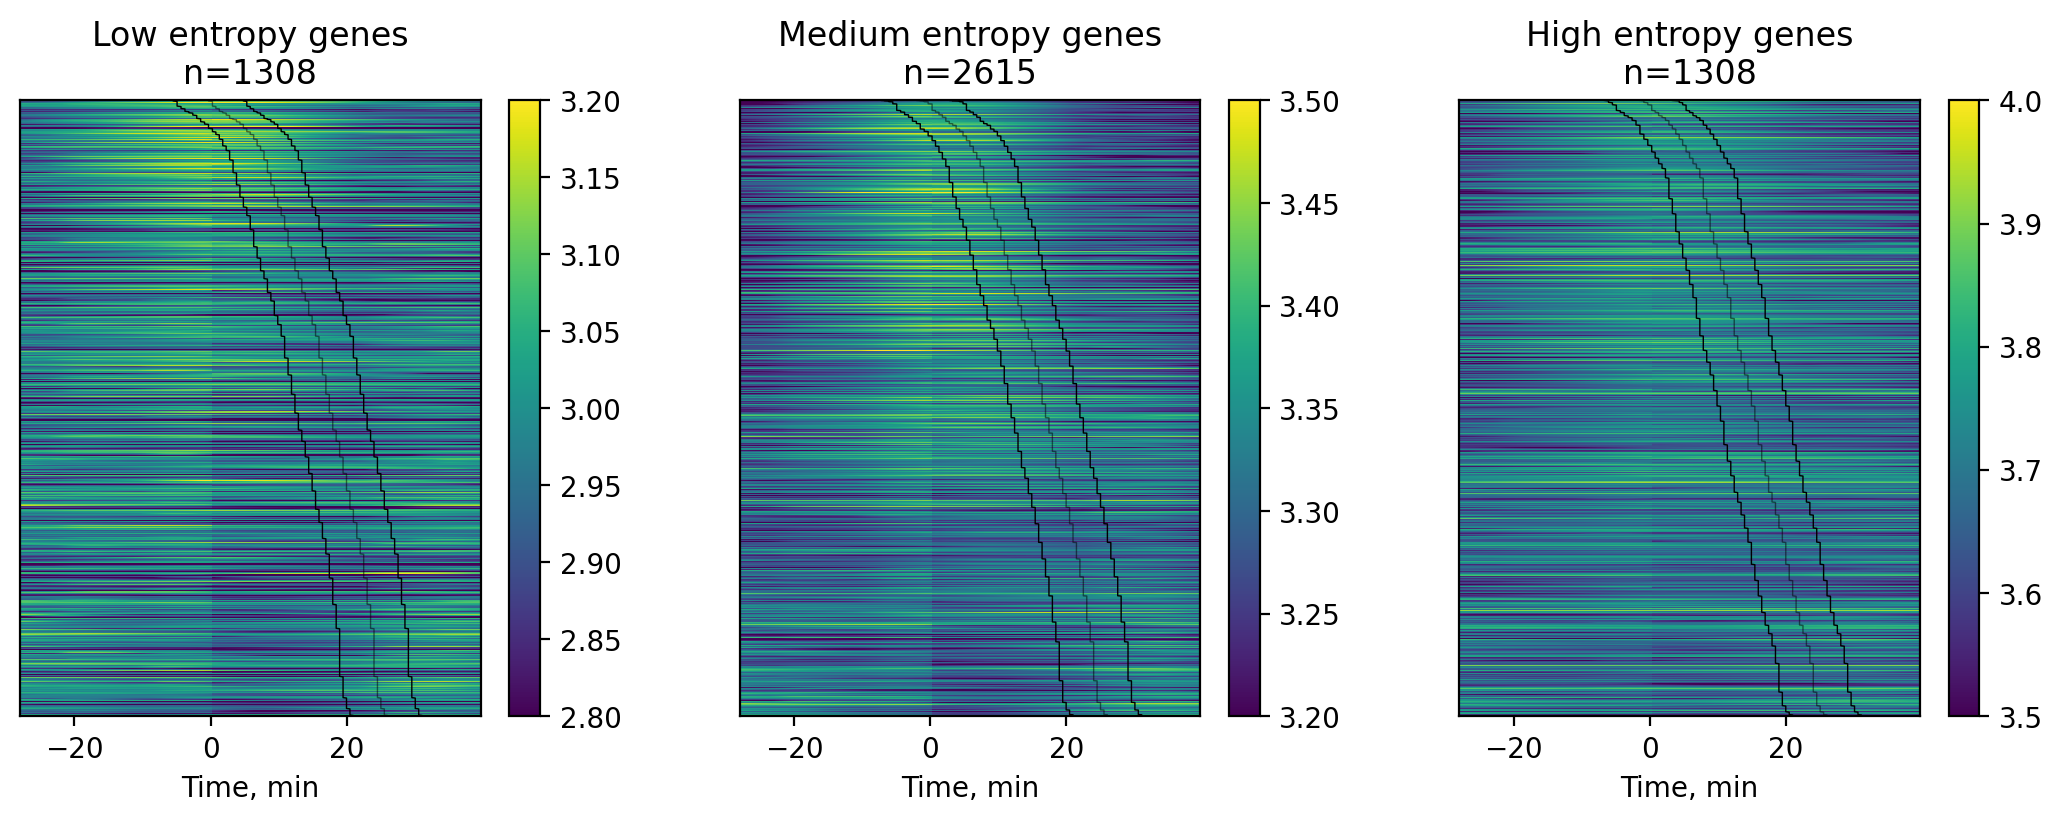

In [793]:
gene_chrom_repl_analysis.set_entropy_vs_tx_df(mode='avg_delta_5_replication')
gene_chrom_repl_analysis.plot_hi_lo_entropy_hm_analysis()

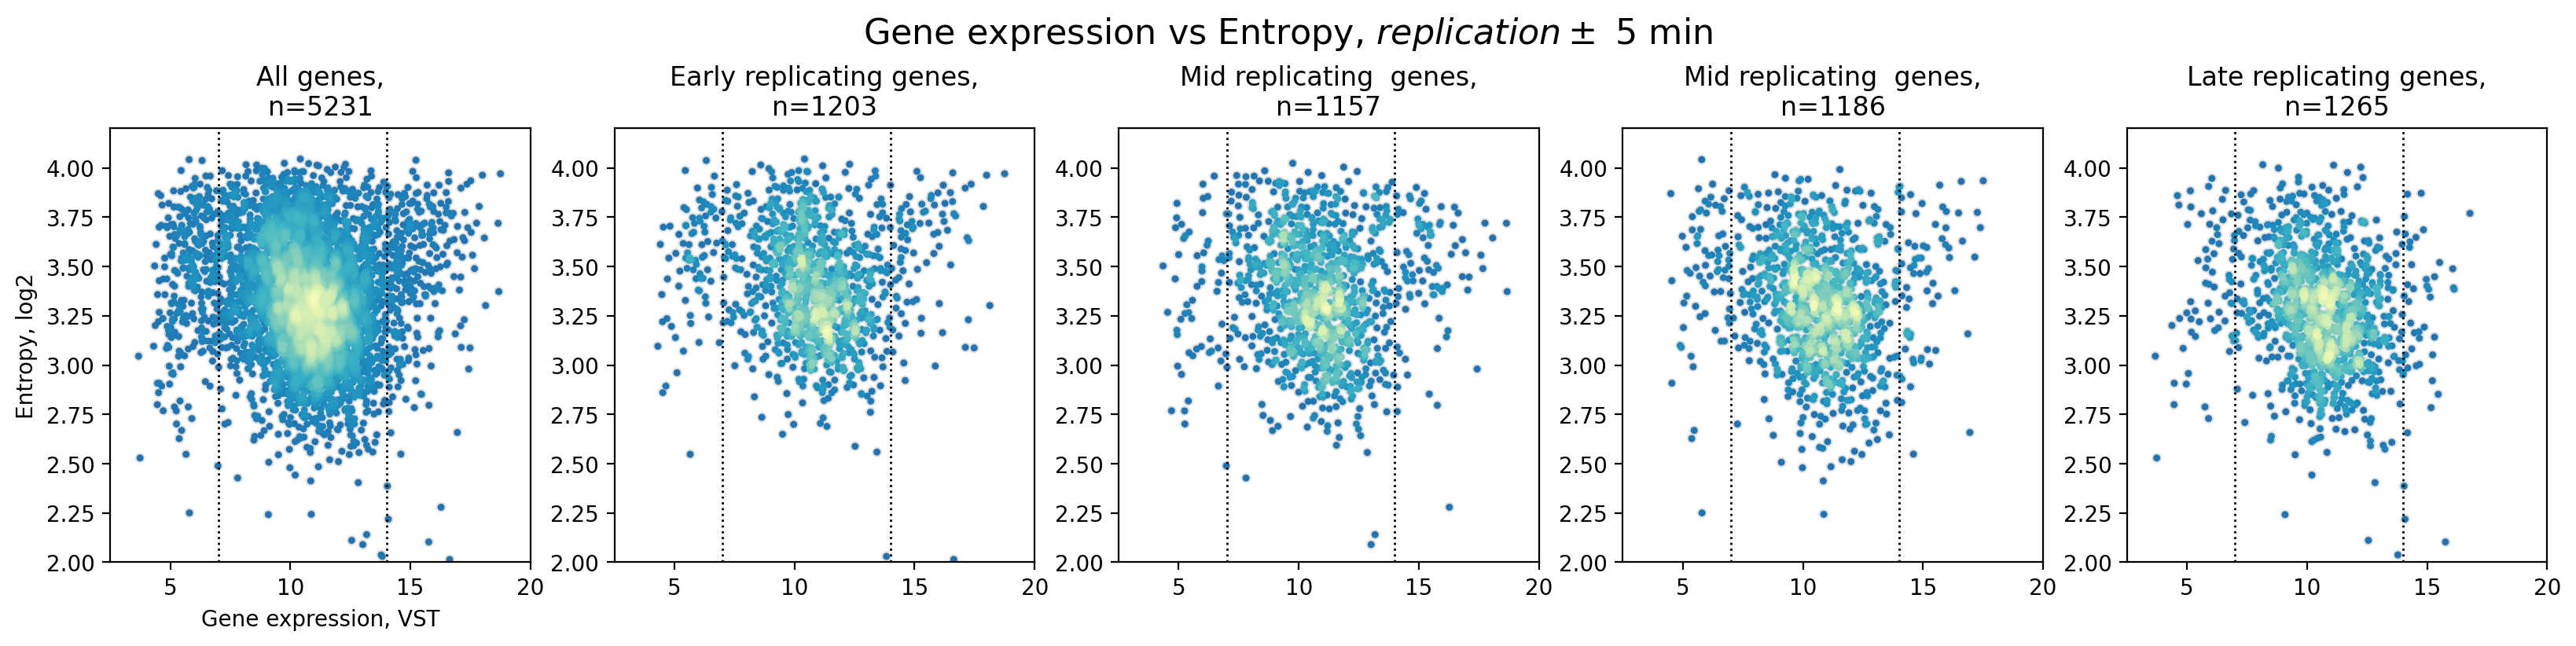

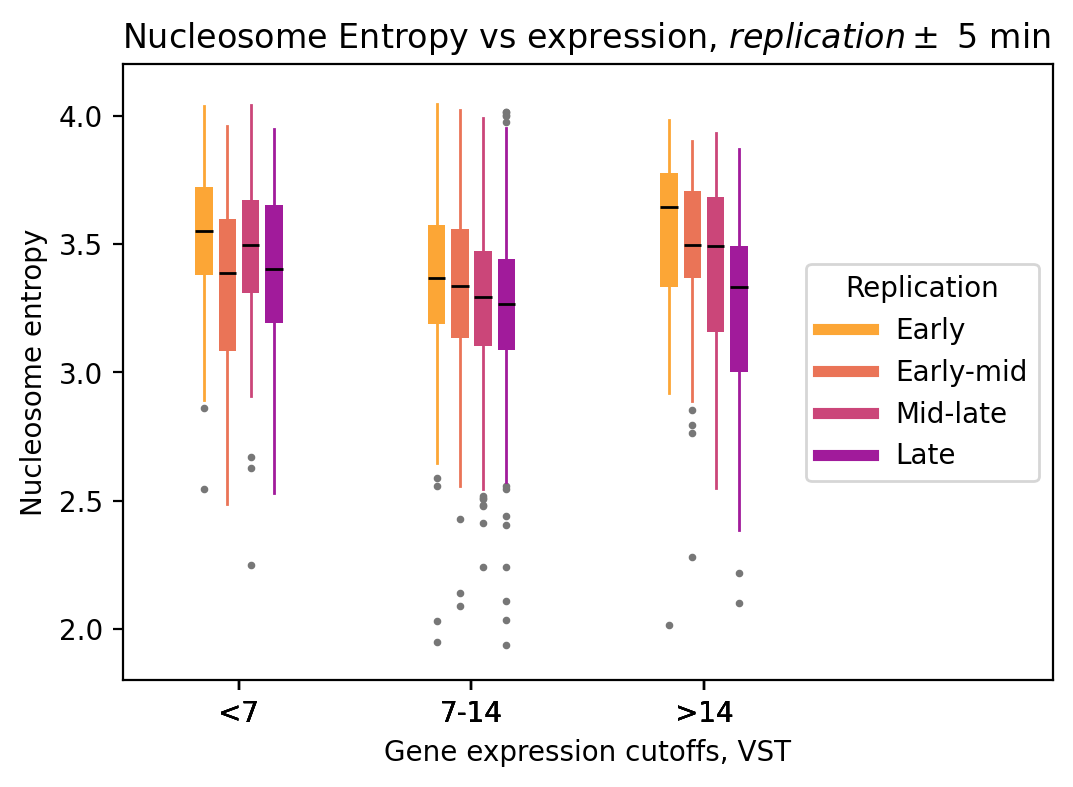

In [802]:
gene_chrom_repl_analysis.plot_entropy_vs_expression_analysis(x_cutoffs=x_cutoffs)
gene_chrom_repl_analysis.plot_box_plot_entropy_ge(x_cutoffs)

**Reflections:** This story shows a snapshot of the entropy. It, shows the difference in entropy at replication time for highly transcribed genes.

But does not say anything yet about the cycling nature of the expression nor entropy. How can we further advance this story to get a sense of replication for transcriptional regulation?

**Goal:** Discern: 
- Are the entropy values and expression dynamic/cycling for thse genes?
    - If so, are they at replication time or elsewhere?
        - There can be regulational implications for either case.
- Can the heatmap of the entire timecourse help with this question based on careful segmentation of the gene sets?

**Possible tasks:**
- Create a heatmap of the time course for entropy separated by gene expression.
- How does the direction of gene transcription play a role in this analysis?
    - Is this the time to start looking at those gene segments?
    

Text(0.5, 1.0, 'High transcription genes\nduring replication, n=316')

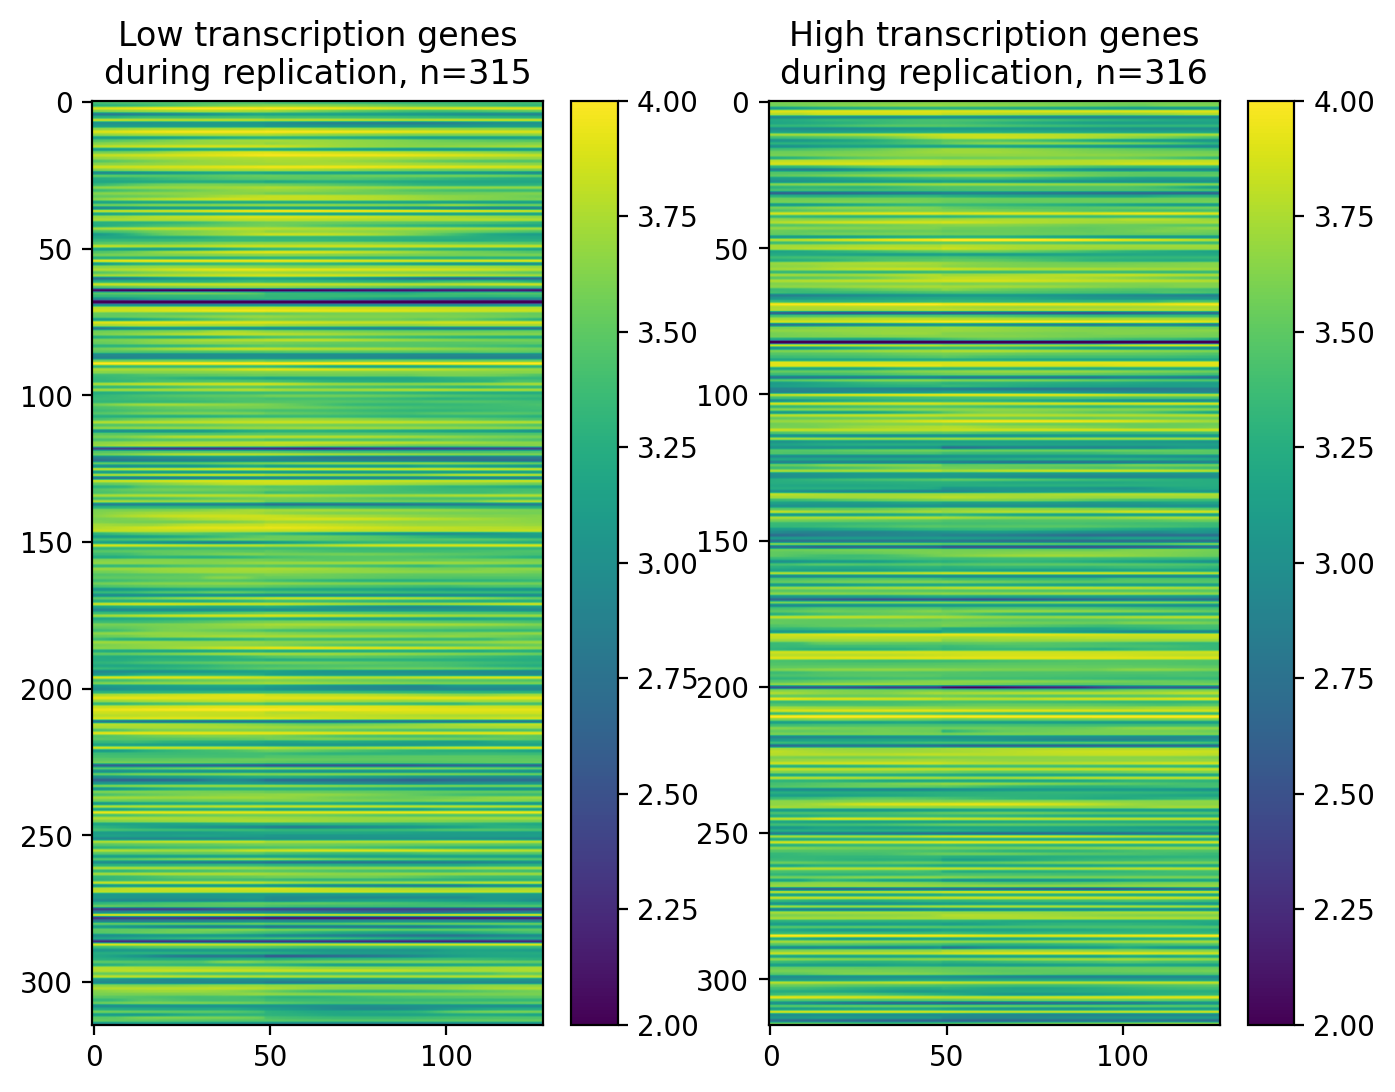

In [868]:

# Get the group cutoffs for tx during replication
gene_entropy_tx_w_tx_cutoffs = gene_chrom_repl_analysis.ge_get_cutoffs_at_repl(x_cutoffs)
gene_entropy_tx_w_tx_cutoffs = gene_entropy_tx_w_tx_cutoffs.sort_values('replication_timing')

# Plot the heatmap of the entropy and expression for these gene groups
# We will care most about the high expression group.

nuc_entropy = gene_chrom_repl_analysis.entropy_df

tx_groups = gene_entropy_tx_w_tx_cutoffs.group_name.unique()

# High expression genes at replication time
hi_tx_group = tx_groups[-1]
hi_tx_genes = gene_entropy_tx_w_tx_cutoffs[\
    gene_entropy_tx_w_tx_cutoffs.group_name == hi_tx_group]

lo_tx_group = tx_groups[0]
lo_tx_genes = gene_entropy_tx_w_tx_cutoffs[\
    gene_entropy_tx_w_tx_cutoffs.group_name == lo_tx_group]

def plot_hm(dat, vmin=2, vmax=4):
    plt.imshow(dat, aspect='auto', vmin=vmin, vmax=vmax)

# Let's plot the heatmap of the entropy in the time course
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
dat = nuc_entropy.loc[lo_tx_genes.index]
plt.title(f"Low transcription genes\nduring replication, n={len(dat)}")
plot_hm(dat)
plt.colorbar()

plt.subplot(1, 2, 2)
dat = nuc_entropy.loc[hi_tx_genes.index]
plot_hm(dat)
plt.colorbar()
plt.title(f"High transcription genes\nduring replication, n={len(dat)}")

# It is difficult to discern patterns because different genes appear to have different
# basal levels of expression. (value of change in entropy model)

# Our story is based around high transcription genes at replication
# So let's drill into those genes and see if we can see the entropy pattern
# among early and late genes, we may need to split up the entropy values
# to actually see the patterns.

Text(0.5, 1.0, 'Distribution of entropy values during replication')

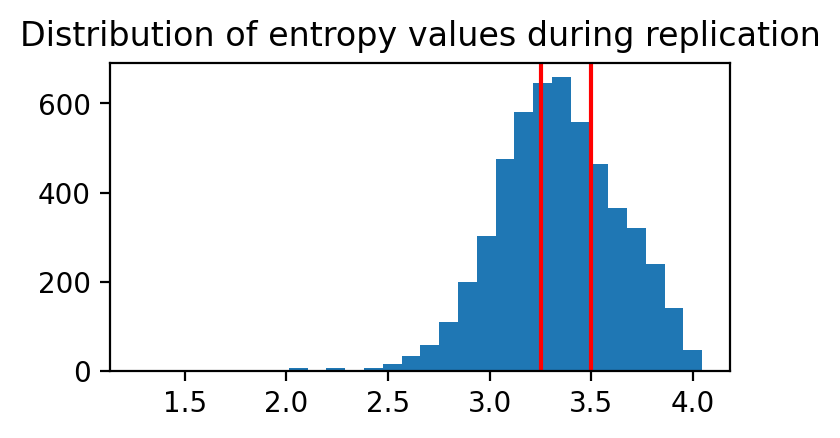

In [861]:
# What are appropriate cutoff values that would discern the early and late tx genes?
# Refer back to the scatter plot. The early and late replicated genes
# appear to be separated by these cutoffs
entropy_cutoffs = 3.25, 3.5
plt.figure(figsize=(4, 2))
plt.hist(gene_entropy_tx_w_tx_cutoffs.entropy_value, bins=30)
for e in entropy_cutoffs:
    plt.axvline(e, c='red')
plt.title("Distribution of entropy values during replication")

Text(0.5, 1.0, 'High Tx, High entropy\nduring replication, n=149')

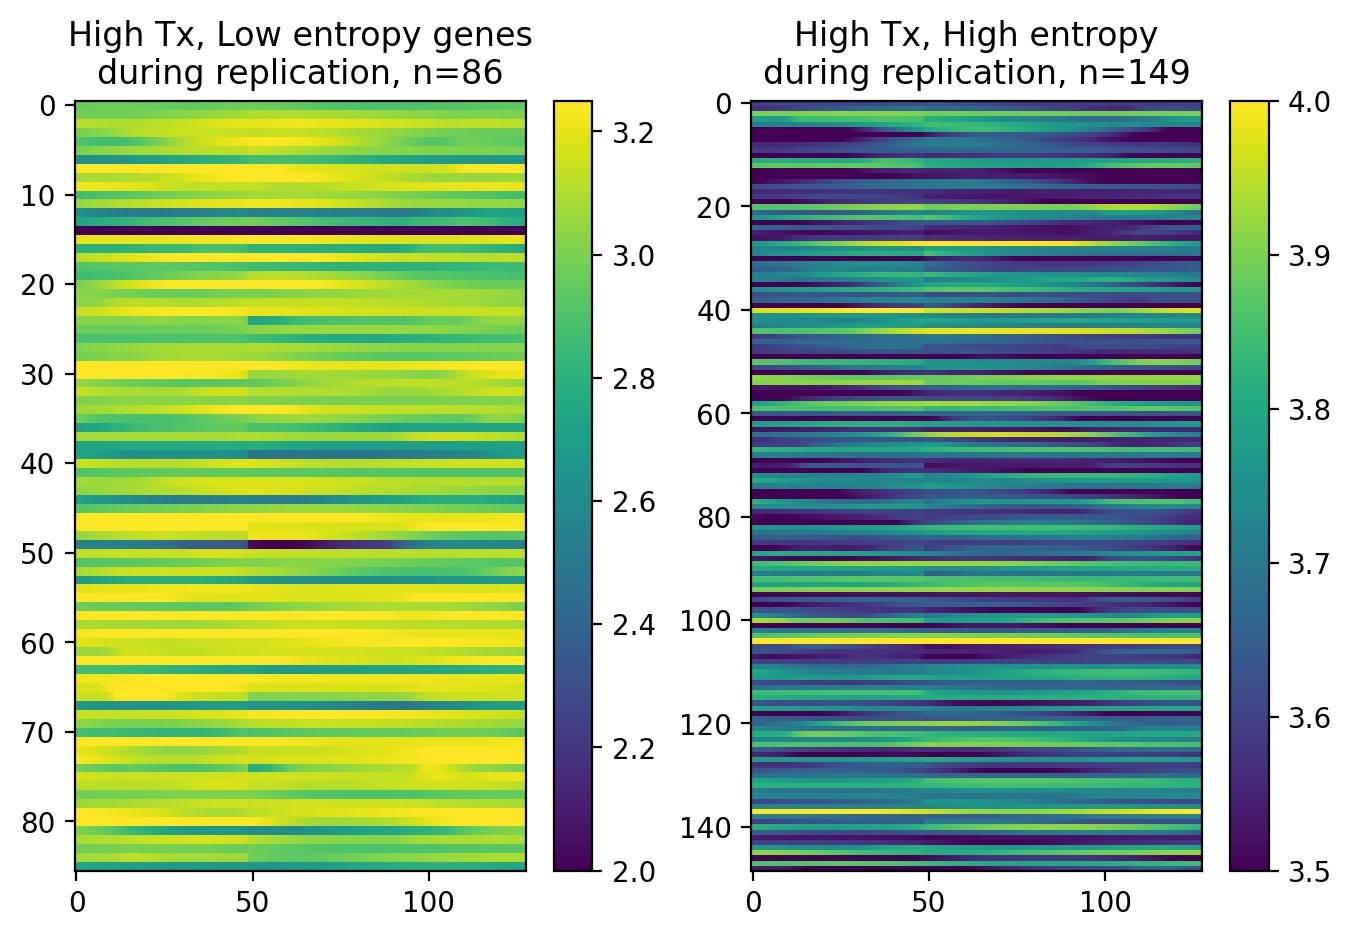

In [872]:
low_e_hi_tx_genes = hi_tx_genes[hi_tx_genes.entropy_value < entropy_cutoffs[0]]
hi_e_hi_tx_genes = hi_tx_genes[hi_tx_genes.entropy_value > entropy_cutoffs[1]]

plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
dat = nuc_entropy.loc[low_e_hi_tx_genes.index]
plt.title(f"High Tx, Low entropy genes\nduring replication, n={len(dat)}")
plot_hm(dat, vmin=2, vmax=3.25)
plt.colorbar()

plt.subplot(1, 2, 2)
dat = nuc_entropy.loc[hi_e_hi_tx_genes.index]
plot_hm(dat, vmin=3.5, vmax=4)
plt.colorbar()
plt.title(f"High Tx, High entropy\nduring replication, n={len(dat)}")


In [ ]:
# Reflect

